<a href="https://colab.research.google.com/github/AshokGit544/Enterprise-Finance-Semantic-Data-Catalog/blob/main/enterprise_finance_semantic_data_catalog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project directory: /content/enterprise_finance_semantic_data_catalog_output

Sample recommendation
User query: show overdue payment percentage by vendor and posting month
Recommended primary table: vendor_metric_summary
Recommended columns: overdue_pct
Top glossary term: Posting Month



,table_name,table_purpose,grain,primary_key,business_domain,catalog_document,similarity_score
0,vendor_metric_summary,Aggregated vendor-level finance metrics such a...,One row per vendor,vendor_id,Vendor Analytics,Table vendor_metric_summary belongs to Vendor ...,0.242268
1,vendors,Vendor master data containing supplier profile...,One row per vendor,vendor_id,Vendor Governance,Table vendors belongs to Vendor Governance. Pu...,0.163858
2,finance_metric_mart,Aggregated monthly finance KPI mart by departm...,"One row per posting month, department, and GL ...",posting_month + department + gl_type,Reporting,Table finance_metric_mart belongs to Reporting...,0.159857


,table_name,column_name,column_definition,column_role,data_type,catalog_document,similarity_score
0,finance_enriched_model,is_overdue,Flag showing overdue payment,measure,integer,Column is_overdue in table finance_enriched_mo...,0.275130
1,vendor_metric_summary,overdue_pct,Percentage of overdue vendor invoices,measure,decimal,Column overdue_pct in table vendor_metric_summ...,0.240781
2,finance_metric_mart,overdue_pct,Percentage of overdue invoices,measure,decimal,Column overdue_pct in table finance_metric_mar...,0.201387
3,finance_enriched_model,posting_month,Monthly reporting period derived from posting ...,dimension,string,Column posting_month in table finance_enriched...,0.109594
4,finance_transactions,payment_date,Invoice payment date,date,date,Column payment_date in table finance_transacti...,0.079011
5,finance_enriched_model,payment_lag_days,Number of days payment occurred before or afte...,measure,integer,Column payment_lag_days in table finance_enric...,0.074544
6,vendors,vendor_name,Vendor display name,dimension,string,Column vendor_name in table vendors is a dimen...,0.067843
7,vendors,vendor_id,Vendor unique identifier,dimension,string,Column vendor_id in table vendors is a dimensi...,0.065008


,business_term,definition,business_area,related_tables,related_columns,glossary_document,similarity_score
0,Posting Month,Year-month period derived from posting date us...,Reporting,finance_transactions,"posting_date, posting_month",Business term Posting Month belongs to Reporti...,0.308024
1,Overdue Payment,Invoice payment completed after due date based...,Accounts Payable,finance_transactions,"due_date, payment_date, payment_lag_days, status",Business term Overdue Payment belongs to Accou...,0.284114
2,Vendor Risk Rating,Risk classification assigned to vendor for mon...,Vendor Governance,vendors,"vendor_id, vendor_name, risk_rating",Business term Vendor Risk Rating belongs to Ve...,0.126632


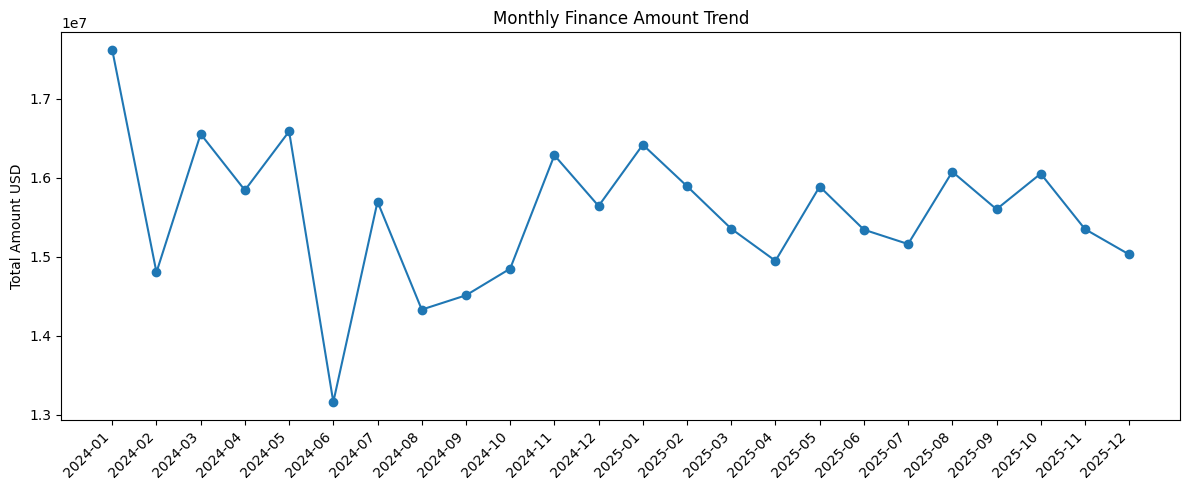

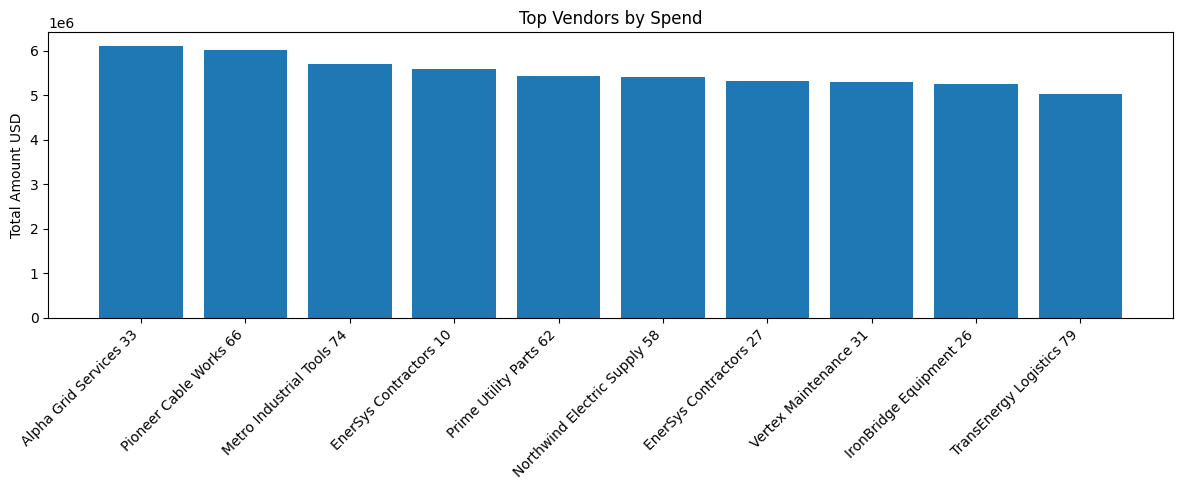


Table catalog


,table_name,business_domain,grain,primary_key
0,vendors,Vendor Governance,One row per vendor,vendor_id
1,cost_centers,Controlling,One row per cost center,cost_center_id
2,profit_centers,Profitability Analysis,One row per profit center,profit_center_id
3,gl_accounts,General Ledger,One row per general ledger account,gl_account
4,finance_transactions,Accounts Payable,One row per finance document,document_id
5,finance_enriched_model,Finance Analytics,One row per finance document,document_id
6,finance_metric_mart,Reporting,"One row per posting month, department, and GL ...",posting_month + department + gl_type
7,vendor_metric_summary,Vendor Analytics,One row per vendor,vendor_id



Column catalog sample


,table_name,column_name,column_definition,column_role,data_type,catalog_document
0,vendors,vendor_id,Vendor unique identifier,dimension,string,Column vendor_id in table vendors is a dimensi...
1,vendors,vendor_name,Vendor display name,dimension,string,Column vendor_name in table vendors is a dimen...
2,vendors,vendor_category,Vendor business category,dimension,string,Column vendor_category in table vendors is a d...
3,vendors,risk_rating,Vendor risk classification,dimension,string,Column risk_rating in table vendors is a dimen...
4,cost_centers,cost_center_id,Cost center unique identifier,dimension,string,Column cost_center_id in table cost_centers is...
5,cost_centers,cost_center_name,Cost center business name,dimension,string,Column cost_center_name in table cost_centers ...
6,cost_centers,department,Department owning the cost center,dimension,string,Column department in table cost_centers is a d...
7,profit_centers,profit_center_id,Profit center unique identifier,dimension,string,Column profit_center_id in table profit_center...
8,profit_centers,profit_center_name,Profit center business name,dimension,string,Column profit_center_name in table profit_cent...
9,gl_accounts,gl_account,General ledger account number,dimension,string,Column gl_account in table gl_accounts is a di...



Business glossary


,business_term,business_area,definition
0,Vendor Spend,Accounts Payable,Total amount paid or posted against a vendor a...
1,Cost Center Spend,Controlling,Total transaction amount allocated to a cost c...
2,Overdue Payment,Accounts Payable,Invoice payment completed after due date based...
3,GL Spend,General Ledger,Total finance amount posted against a general ...
4,Profit Center Allocation,Profitability Analysis,Finance transaction distribution across profit...
5,Posting Month,Reporting,Year-month period derived from posting date us...
6,Vendor Risk Rating,Vendor Governance,Risk classification assigned to vendor for mon...
7,Capital Spend,Capital Accounting,Transaction amount posted to capital general l...



Query recommendations


,business_question,recommended_table,top_glossary_term,top_similarity_score,recommendation_text
0,show total vendor spend by month,vendor_metric_summary,Vendor Spend,0.2640,User query: show total vendor spend by month\n...
1,find overdue payment percentage by department,vendor_metric_summary,Overdue Payment,0.1802,User query: find overdue payment percentage by...
2,show top vendors by total amount,vendors,Vendor Spend,0.1629,User query: show top vendors by total amount\n...
3,show capital spend by posting month,finance_metric_mart,Posting Month,0.2122,User query: show capital spend by posting mont...
4,find transaction count by cost center,cost_centers,Cost Center Spend,0.3087,User query: find transaction count by cost cen...



Generated files:
- business_glossary.csv
- column_catalog.csv
- cost_centers.csv
- dataset_usage_summary.csv
- finance_enriched_model.csv
- finance_metric_mart.csv
- finance_transactions.csv
- gl_accounts.csv
- profit_centers.csv
- query_recommendations.csv
- table_catalog.csv
- vendor_metric_summary.csv
- vendors.csv


In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib

import warnings
warnings.filterwarnings("ignore")

import random
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)

PROJECT_DIR = Path("enterprise_finance_semantic_data_catalog_output")
PROJECT_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR.resolve())

def make_vendors(n=90):
    vendor_bases = [
        "Alpha Grid Services", "Northwind Electric Supply", "GreenVolt Systems", "Prime Utility Parts",
        "TransEnergy Logistics", "Vertex Maintenance", "BluePeak Consulting", "SolarEdge Components",
        "Metro Industrial Tools", "Crescent Field Ops", "Pioneer Cable Works", "Helios Analytics",
        "Summit Procurement", "IronBridge Equipment", "EnerSys Contractors", "Utility Edge Networks"
    ]
    categories = ["Maintenance", "IT Services", "Electrical Components", "Logistics", "Consulting", "Field Services"]
    rows = []
    for i in range(1, n + 1):
        rows.append({
            "vendor_id": f"V{i:04d}",
            "vendor_name": random.choice(vendor_bases) + f" {i}",
            "vendor_category": random.choice(categories),
            "vendor_state": random.choice(["NY", "CT", "ME", "MA", "PA", "NJ", "RI"]),
            "payment_terms_days": random.choice([15, 30, 45, 60]),
            "risk_rating": random.choice(["Low", "Medium", "High"])
        })
    return pd.DataFrame(rows)

def make_cost_centers():
    rows = [
        ("CC100", "Transmission Operations", "Operations"),
        ("CC110", "Distribution Maintenance", "Operations"),
        ("CC120", "Substation Engineering", "Engineering"),
        ("CC130", "Renewables Program", "Strategy"),
        ("CC140", "Customer Support", "Customer Ops"),
        ("CC150", "IT Shared Services", "Technology"),
        ("CC160", "Finance Operations", "Finance"),
        ("CC170", "Vegetation Management", "Field Ops"),
        ("CC180", "Grid Modernization", "Engineering"),
        ("CC190", "Regulatory Affairs", "Corporate")
    ]
    return pd.DataFrame(rows, columns=["cost_center_id", "cost_center_name", "department"])

def make_profit_centers():
    rows = [
        ("PC200", "Electric Distribution East", "East"),
        ("PC210", "Electric Distribution West", "West"),
        ("PC220", "Gas and Field Services", "North"),
        ("PC230", "Renewables and Storage", "Enterprise"),
        ("PC240", "Corporate Shared Services", "Corporate")
    ]
    return pd.DataFrame(rows, columns=["profit_center_id", "profit_center_name", "region_group"])

def make_gl_accounts():
    rows = [
        ("400100", "Revenue - Energy Delivery", "Revenue"),
        ("500100", "Opex - Maintenance", "Expense"),
        ("500200", "Opex - IT Services", "Expense"),
        ("500300", "Opex - Contractors", "Expense"),
        ("500400", "Opex - Logistics", "Expense"),
        ("500500", "Opex - Vegetation Mgmt", "Expense"),
        ("500600", "Opex - Consulting", "Expense"),
        ("500700", "Opex - Emergency Repairs", "Expense"),
        ("500800", "Capex - Grid Modernization", "Capital"),
        ("500900", "Capex - Substation Upgrades", "Capital"),
        ("110100", "Accounts Payable", "Liability"),
        ("130100", "Cash", "Asset")
    ]
    return pd.DataFrame(rows, columns=["gl_account", "gl_account_name", "gl_type"])

vendors = make_vendors()
cost_centers = make_cost_centers()
profit_centers = make_profit_centers()
gl_accounts = make_gl_accounts()

vendors.to_csv(PROJECT_DIR / "vendors.csv", index=False)
cost_centers.to_csv(PROJECT_DIR / "cost_centers.csv", index=False)
profit_centers.to_csv(PROJECT_DIR / "profit_centers.csv", index=False)
gl_accounts.to_csv(PROJECT_DIR / "gl_accounts.csv", index=False)

descriptions = [
    "substation maintenance support",
    "vegetation clearing around power lines",
    "grid inspection contractor services",
    "cybersecurity monitoring support",
    "cloud cost optimization consulting",
    "field equipment transportation",
    "metering systems enhancement",
    "SCADA support services",
    "storm response contractor mobilization",
    "distribution pole inspection",
    "asset reliability assessment",
    "emergency transformer replacement",
    "temporary field crew support",
    "circuit restoration activities",
    "renewables integration support",
    "substation modernization project"
]

def generate_finance_transactions(num_rows=6000):
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2025, 12, 31)
    date_range_days = (end_date - start_date).days
    rows = []

    for i in range(1, num_rows + 1):
        vendor = vendors.sample(1).iloc[0]
        cc = cost_centers.sample(1).iloc[0]
        pc = profit_centers.sample(1).iloc[0]
        gl = gl_accounts.sample(1).iloc[0]

        posting_date = start_date + timedelta(days=random.randint(0, date_range_days))
        due_date = posting_date + timedelta(days=int(vendor["payment_terms_days"]))
        payment_date = due_date + timedelta(days=random.randint(-3, 25))

        amount = random.uniform(2000, 110000)
        if vendor["vendor_category"] == "Consulting":
            amount *= 1.2
        if cc["cost_center_name"] == "Vegetation Management":
            amount *= 1.15
        if gl["gl_type"] == "Capital":
            amount *= 1.25

        rows.append({
            "document_id": f"DOC{i:06d}",
            "invoice_id": f"INV{i:06d}",
            "posting_date": posting_date.date().isoformat(),
            "due_date": due_date.date().isoformat(),
            "payment_date": payment_date.date().isoformat(),
            "vendor_id": vendor["vendor_id"],
            "cost_center_id": cc["cost_center_id"],
            "profit_center_id": pc["profit_center_id"],
            "gl_account": gl["gl_account"],
            "amount_usd": round(amount, 2),
            "currency": "USD",
            "description": random.choice(descriptions),
            "status": random.choice(["POSTED", "APPROVED", "PAID", "HOLD", "PENDING_REVIEW"]),
            "source_system": random.choice(["SAP_FI", "SAP_AP", "ERP_STAGE"])
        })

    return pd.DataFrame(rows)

finance_transactions = generate_finance_transactions()
finance_transactions.to_csv(PROJECT_DIR / "finance_transactions.csv", index=False)

df = (
    finance_transactions
    .merge(vendors, on="vendor_id", how="left")
    .merge(cost_centers, on="cost_center_id", how="left")
    .merge(profit_centers, on="profit_center_id", how="left")
    .merge(gl_accounts, on="gl_account", how="left")
)

df["posting_date"] = pd.to_datetime(df["posting_date"])
df["due_date"] = pd.to_datetime(df["due_date"])
df["payment_date"] = pd.to_datetime(df["payment_date"])
df["posting_month"] = df["posting_date"].dt.to_period("M").astype(str)
df["payment_lag_days"] = (df["payment_date"] - df["due_date"]).dt.days
df["is_overdue"] = (df["payment_lag_days"] > 0).astype(int)

df.to_csv(PROJECT_DIR / "finance_enriched_model.csv", index=False)

metric_mart = (
    df.groupby(["posting_month", "department", "gl_type"], as_index=False)
    .agg(
        transaction_count=("document_id", "count"),
        total_amount_usd=("amount_usd", "sum"),
        avg_amount_usd=("amount_usd", "mean"),
        overdue_invoices=("is_overdue", "sum")
    )
    .sort_values(["posting_month", "department", "gl_type"])
)

metric_mart["overdue_pct"] = (
    metric_mart["overdue_invoices"] / metric_mart["transaction_count"] * 100
).round(2)

metric_mart.to_csv(PROJECT_DIR / "finance_metric_mart.csv", index=False)

top_vendors = (
    df.groupby(["vendor_id", "vendor_name", "vendor_category"], as_index=False)
    .agg(
        transaction_count=("document_id", "count"),
        total_amount_usd=("amount_usd", "sum"),
        overdue_invoices=("is_overdue", "sum")
    )
    .sort_values("total_amount_usd", ascending=False)
)

top_vendors["overdue_pct"] = (
    top_vendors["overdue_invoices"] / top_vendors["transaction_count"] * 100
).round(2)

top_vendors.to_csv(PROJECT_DIR / "vendor_metric_summary.csv", index=False)

business_glossary = pd.DataFrame([
    {
        "business_term": "Vendor Spend",
        "definition": "Total amount paid or posted against a vendor across finance transactions.",
        "business_area": "Accounts Payable",
        "related_tables": "finance_transactions, vendors",
        "related_columns": "vendor_id, vendor_name, amount_usd, posting_date"
    },
    {
        "business_term": "Cost Center Spend",
        "definition": "Total transaction amount allocated to a cost center for operational or capital activities.",
        "business_area": "Controlling",
        "related_tables": "finance_transactions, cost_centers",
        "related_columns": "cost_center_id, cost_center_name, amount_usd, posting_date"
    },
    {
        "business_term": "Overdue Payment",
        "definition": "Invoice payment completed after due date based on payment lag days greater than zero.",
        "business_area": "Accounts Payable",
        "related_tables": "finance_transactions",
        "related_columns": "due_date, payment_date, payment_lag_days, status"
    },
    {
        "business_term": "GL Spend",
        "definition": "Total finance amount posted against a general ledger account.",
        "business_area": "General Ledger",
        "related_tables": "finance_transactions, gl_accounts",
        "related_columns": "gl_account, gl_account_name, amount_usd"
    },
    {
        "business_term": "Profit Center Allocation",
        "definition": "Finance transaction distribution across profit centers for business segment reporting.",
        "business_area": "Profitability Analysis",
        "related_tables": "finance_transactions, profit_centers",
        "related_columns": "profit_center_id, profit_center_name, amount_usd"
    },
    {
        "business_term": "Posting Month",
        "definition": "Year-month period derived from posting date used for monthly finance reporting.",
        "business_area": "Reporting",
        "related_tables": "finance_transactions",
        "related_columns": "posting_date, posting_month"
    },
    {
        "business_term": "Vendor Risk Rating",
        "definition": "Risk classification assigned to vendor for monitoring and control purposes.",
        "business_area": "Vendor Governance",
        "related_tables": "vendors",
        "related_columns": "vendor_id, vendor_name, risk_rating"
    },
    {
        "business_term": "Capital Spend",
        "definition": "Transaction amount posted to capital general ledger accounts for long-term investments.",
        "business_area": "Capital Accounting",
        "related_tables": "finance_transactions, gl_accounts",
        "related_columns": "gl_account, gl_type, amount_usd"
    }
])

business_glossary.to_csv(PROJECT_DIR / "business_glossary.csv", index=False)

catalog_rows = [
    {
        "table_name": "vendors",
        "table_purpose": "Vendor master data containing supplier profile, category, state, payment terms, and risk rating.",
        "grain": "One row per vendor",
        "primary_key": "vendor_id",
        "business_domain": "Vendor Governance"
    },
    {
        "table_name": "cost_centers",
        "table_purpose": "Cost center master data used to allocate operational spend and department ownership.",
        "grain": "One row per cost center",
        "primary_key": "cost_center_id",
        "business_domain": "Controlling"
    },
    {
        "table_name": "profit_centers",
        "table_purpose": "Profit center master data used for segment and business unit reporting.",
        "grain": "One row per profit center",
        "primary_key": "profit_center_id",
        "business_domain": "Profitability Analysis"
    },
    {
        "table_name": "gl_accounts",
        "table_purpose": "General ledger account master with account name and account type.",
        "grain": "One row per general ledger account",
        "primary_key": "gl_account",
        "business_domain": "General Ledger"
    },
    {
        "table_name": "finance_transactions",
        "table_purpose": "Raw finance transaction feed containing document, invoice, dates, amounts, status, and source system.",
        "grain": "One row per finance document",
        "primary_key": "document_id",
        "business_domain": "Accounts Payable"
    },
    {
        "table_name": "finance_enriched_model",
        "table_purpose": "Curated finance model joining transactions with vendor, cost center, profit center, and GL data.",
        "grain": "One row per finance document",
        "primary_key": "document_id",
        "business_domain": "Finance Analytics"
    },
    {
        "table_name": "finance_metric_mart",
        "table_purpose": "Aggregated monthly finance KPI mart by department and GL type for reporting and BI.",
        "grain": "One row per posting month, department, and GL type",
        "primary_key": "posting_month + department + gl_type",
        "business_domain": "Reporting"
    },
    {
        "table_name": "vendor_metric_summary",
        "table_purpose": "Aggregated vendor-level finance metrics such as spend, transaction count, and overdue percentage.",
        "grain": "One row per vendor",
        "primary_key": "vendor_id",
        "business_domain": "Vendor Analytics"
    }
]

table_catalog = pd.DataFrame(catalog_rows)
table_catalog.to_csv(PROJECT_DIR / "table_catalog.csv", index=False)

column_catalog_rows = [
    ("vendors", "vendor_id", "Vendor unique identifier", "dimension", "string"),
    ("vendors", "vendor_name", "Vendor display name", "dimension", "string"),
    ("vendors", "vendor_category", "Vendor business category", "dimension", "string"),
    ("vendors", "risk_rating", "Vendor risk classification", "dimension", "string"),
    ("cost_centers", "cost_center_id", "Cost center unique identifier", "dimension", "string"),
    ("cost_centers", "cost_center_name", "Cost center business name", "dimension", "string"),
    ("cost_centers", "department", "Department owning the cost center", "dimension", "string"),
    ("profit_centers", "profit_center_id", "Profit center unique identifier", "dimension", "string"),
    ("profit_centers", "profit_center_name", "Profit center business name", "dimension", "string"),
    ("gl_accounts", "gl_account", "General ledger account number", "dimension", "string"),
    ("gl_accounts", "gl_account_name", "General ledger account name", "dimension", "string"),
    ("gl_accounts", "gl_type", "General ledger account type", "dimension", "string"),
    ("finance_transactions", "document_id", "Finance document identifier", "key", "string"),
    ("finance_transactions", "invoice_id", "Invoice identifier", "key", "string"),
    ("finance_transactions", "posting_date", "Date finance document was posted", "date", "date"),
    ("finance_transactions", "due_date", "Invoice due date", "date", "date"),
    ("finance_transactions", "payment_date", "Invoice payment date", "date", "date"),
    ("finance_transactions", "amount_usd", "Transaction amount in USD", "measure", "decimal"),
    ("finance_transactions", "status", "Transaction processing status", "dimension", "string"),
    ("finance_transactions", "source_system", "Origin system of transaction", "dimension", "string"),
    ("finance_enriched_model", "payment_lag_days", "Number of days payment occurred before or after due date", "measure", "integer"),
    ("finance_enriched_model", "is_overdue", "Flag showing overdue payment", "measure", "integer"),
    ("finance_enriched_model", "posting_month", "Monthly reporting period derived from posting date", "dimension", "string"),
    ("finance_metric_mart", "transaction_count", "Count of finance transactions", "measure", "integer"),
    ("finance_metric_mart", "total_amount_usd", "Total amount in USD", "measure", "decimal"),
    ("finance_metric_mart", "avg_amount_usd", "Average transaction amount in USD", "measure", "decimal"),
    ("finance_metric_mart", "overdue_pct", "Percentage of overdue invoices", "measure", "decimal"),
    ("vendor_metric_summary", "total_amount_usd", "Total vendor spend in USD", "measure", "decimal"),
    ("vendor_metric_summary", "overdue_pct", "Percentage of overdue vendor invoices", "measure", "decimal")
]

column_catalog = pd.DataFrame(
    column_catalog_rows,
    columns=["table_name", "column_name", "column_definition", "column_role", "data_type"]
)
column_catalog.to_csv(PROJECT_DIR / "column_catalog.csv", index=False)

table_catalog["catalog_document"] = table_catalog.apply(
    lambda r: f"Table {r['table_name']} belongs to {r['business_domain']}. "
              f"Purpose: {r['table_purpose']} "
              f"Grain: {r['grain']}. "
              f"Primary key: {r['primary_key']}.",
    axis=1
)

column_catalog["catalog_document"] = column_catalog.apply(
    lambda r: f"Column {r['column_name']} in table {r['table_name']} is a {r['column_role']} field with data type {r['data_type']}. "
              f"Definition: {r['column_definition']}.",
    axis=1
)

business_glossary["glossary_document"] = business_glossary.apply(
    lambda r: f"Business term {r['business_term']} belongs to {r['business_area']}. "
              f"Definition: {r['definition']} "
              f"Related tables: {r['related_tables']}. "
              f"Related columns: {r['related_columns']}.",
    axis=1
)

table_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
table_matrix = table_vectorizer.fit_transform(table_catalog["catalog_document"])

column_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
column_matrix = column_vectorizer.fit_transform(column_catalog["catalog_document"])

glossary_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
glossary_matrix = glossary_vectorizer.fit_transform(business_glossary["glossary_document"])

def search_tables(query, top_k=5):
    q = table_vectorizer.transform([query])
    sims = cosine_similarity(q, table_matrix)[0]
    idx = np.argsort(sims)[::-1][:top_k]
    result = table_catalog.iloc[idx].copy()
    result["similarity_score"] = sims[idx]
    return result.reset_index(drop=True)

def search_columns(query, top_k=8):
    q = column_vectorizer.transform([query])
    sims = cosine_similarity(q, column_matrix)[0]
    idx = np.argsort(sims)[::-1][:top_k]
    result = column_catalog.iloc[idx].copy()
    result["similarity_score"] = sims[idx]
    return result.reset_index(drop=True)

def search_glossary(query, top_k=5):
    q = glossary_vectorizer.transform([query])
    sims = cosine_similarity(q, glossary_matrix)[0]
    idx = np.argsort(sims)[::-1][:top_k]
    result = business_glossary.iloc[idx].copy()
    result["similarity_score"] = sims[idx]
    return result.reset_index(drop=True)

def recommend_dataset_and_fields(user_query, top_k_tables=3, top_k_columns=8):
    table_results = search_tables(user_query, top_k=top_k_tables)
    column_results = search_columns(user_query, top_k=top_k_columns)
    glossary_results = search_glossary(user_query, top_k=3)

    recommended_table = table_results.iloc[0]["table_name"] if not table_results.empty else None
    recommended_columns = column_results[column_results["table_name"] == recommended_table]["column_name"].tolist()

    explanation = (
        f"User query: {user_query}\n"
        f"Recommended primary table: {recommended_table}\n"
        f"Recommended columns: {', '.join(recommended_columns[:8]) if recommended_columns else 'No direct column match'}\n"
        f"Top glossary term: {glossary_results.iloc[0]['business_term'] if not glossary_results.empty else 'N/A'}\n"
    )

    return explanation, table_results, column_results, glossary_results

sample_query = "show overdue payment percentage by vendor and posting month"
sample_explanation, sample_tables, sample_columns, sample_glossary = recommend_dataset_and_fields(sample_query)

print("\nSample recommendation")
print(sample_explanation)
display(sample_tables)
display(sample_columns.head(10))
display(sample_glossary)

query_library = pd.DataFrame([
    {"business_question": "show total vendor spend by month", "expected_table": "finance_enriched_model", "expected_metric": "amount_usd"},
    {"business_question": "find overdue payment percentage by department", "expected_table": "finance_metric_mart", "expected_metric": "overdue_pct"},
    {"business_question": "show top vendors by total amount", "expected_table": "vendor_metric_summary", "expected_metric": "total_amount_usd"},
    {"business_question": "show capital spend by posting month", "expected_table": "finance_metric_mart", "expected_metric": "total_amount_usd"},
    {"business_question": "find transaction count by cost center", "expected_table": "finance_enriched_model", "expected_metric": "document_id"}
])

query_results = []
for _, row in query_library.iterrows():
    explanation, tables_found, cols_found, glossary_found = recommend_dataset_and_fields(row["business_question"])
    query_results.append({
        "business_question": row["business_question"],
        "recommended_table": tables_found.iloc[0]["table_name"] if not tables_found.empty else None,
        "top_glossary_term": glossary_found.iloc[0]["business_term"] if not glossary_found.empty else None,
        "top_similarity_score": round(float(tables_found.iloc[0]["similarity_score"]), 4) if not tables_found.empty else None,
        "recommendation_text": explanation
    })

query_recommendations = pd.DataFrame(query_results)
query_recommendations.to_csv(PROJECT_DIR / "query_recommendations.csv", index=False)

dataset_usage_summary = pd.DataFrame([
    {
        "dataset_name": "finance_transactions",
        "recommended_use": "Raw transactional investigation and source-level reconciliation",
        "best_for_users": "Data engineers, finance operations"
    },
    {
        "dataset_name": "finance_enriched_model",
        "recommended_use": "Detailed finance analysis across vendor, cost center, profit center, and GL joins",
        "best_for_users": "Analysts, finance reporting teams"
    },
    {
        "dataset_name": "finance_metric_mart",
        "recommended_use": "Monthly KPI dashboards and management reporting",
        "best_for_users": "Power BI developers, business users"
    },
    {
        "dataset_name": "vendor_metric_summary",
        "recommended_use": "Vendor performance and overdue monitoring",
        "best_for_users": "Vendor management, accounts payable teams"
    }
])
dataset_usage_summary.to_csv(PROJECT_DIR / "dataset_usage_summary.csv", index=False)

plt.figure(figsize=(12, 5))
monthly_amount = (
    df.groupby("posting_month", as_index=False)
      .agg(total_amount_usd=("amount_usd", "sum"))
      .sort_values("posting_month")
)
plt.plot(monthly_amount["posting_month"], monthly_amount["total_amount_usd"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Finance Amount Trend")
plt.ylabel("Total Amount USD")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_vendor_chart = top_vendors.head(10)
plt.bar(top_vendor_chart["vendor_name"], top_vendor_chart["total_amount_usd"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Vendors by Spend")
plt.ylabel("Total Amount USD")
plt.tight_layout()
plt.show()

print("\nTable catalog")
display(table_catalog[["table_name", "business_domain", "grain", "primary_key"]])

print("\nColumn catalog sample")
display(column_catalog.head(15))

print("\nBusiness glossary")
display(business_glossary[["business_term", "business_area", "definition"]])

print("\nQuery recommendations")
display(query_recommendations)

print("\nGenerated files:")
for p in sorted(PROJECT_DIR.glob("*")):
    print("-", p.name)